# JD Demand Exploration\n
This notebook builds daily demand tables and explores sparsity, variance, and basic distribution stats to guide whether to model by `region_id` or `dc_des`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

In [13]:
b = pd.read_csv('../data/raw/bundle_groups.csv')
display(b)

,order_ID,bundle_skus
0,004135b23a,"['068f4481b3', 'fbce41fd82']"
1,00430c5e38,"['068f4481b3', '2523d051fd']"
2,0071680bc5,"['fbce41fd82', '068f4481b3']"
3,00a6d8739c,"['fbce41fd82', '068f4481b3']"
4,00a7ddff9e,"['068f4481b3', '2523d051fd']"
...,...,...
1979,ff3334ee0b,"['d3e31fdd6e', 'fbce41fd82', 'd3e31fdd6e', '06..."
1980,ff40512a47,"['0bfcedf96d', 'fc728c8ac1']"
1981,ff41c602c0,"['068f4481b3', 'fbce41fd82']"
1982,ff7c5b9ef9,"['068f4481b3', 'fbce41fd82']"


In [2]:
base = Path('.')
orders_path = base / '../data/raw/JD_order_data.csv'
network_path = base / '../data/raw/JD_network_data.csv'

orders = pd.read_csv(orders_path)
network = pd.read_csv(network_path).rename(columns={'region_ID': 'region_id', 'dc_ID': 'dc_des'})

orders['date'] = pd.to_datetime(orders['order_date'], errors='coerce').dt.date
orders = orders.merge(network, on='dc_des', how='left')

print('orders rows:', len(orders))
print('missing region_id:', orders['region_id'].isna().sum())
display(orders.head())

orders rows: 549989
missing region_id: 46282


,order_ID,user_ID,sku_ID,order_date,order_time,quantity,type,promise,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,gift_item,dc_ori,dc_des,date,region_id
0,d0cf5cc6db,0abe9ef2ce,581d5b54c1,2018-03-01,2018-03-01 17:14:25.0,1,2,-,89.0,79.0,0.0,10.0,0.0,0.0,0,4,28,2018-03-01,4.0
1,7444318d01,33a9e56257,067b673f2b,2018-03-01,2018-03-01 11:10:40.0,1,1,2,99.9,53.9,5.0,41.0,0.0,0.0,0,28,28,2018-03-01,4.0
2,f973b01694,4ea3cf408f,623d0a582a,2018-03-01,2018-03-01 09:13:26.0,1,1,2,78.0,58.5,19.5,0.0,0.0,0.0,0,28,28,2018-03-01,4.0
3,8c1cec8d4b,b87cb736cb,fc5289b139,2018-03-01,2018-03-01 21:29:50.0,1,1,2,61.0,35.0,0.0,26.0,0.0,0.0,0,4,28,2018-03-01,4.0
4,d43a33c38a,4829223b6f,623d0a582a,2018-03-01,2018-03-01 19:13:37.0,1,1,1,78.0,53.0,19.0,0.0,0.0,6.0,0,3,16,2018-03-01,NaN


## Build Daily Demand Tables

In [3]:
daily_by_region = (
    orders.groupby(['sku_ID', 'date', 'region_id'], dropna=False)['quantity']
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'demand'})
)

daily_by_dc = (
    orders.groupby(['sku_ID', 'date', 'dc_des'], dropna=False)['quantity']
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'demand'})
)

display(daily_by_region.head())
display(daily_by_dc.head())

,sku_ID,date,region_id,demand
0,000aa92b82,2018-03-03,4.0,1
1,000aa92b82,2018-03-08,4.0,1
2,000aa92b82,2018-03-09,24.0,1
3,000aa92b82,2018-03-10,NaN,1
4,000aa92b82,2018-03-11,5.0,1


,sku_ID,date,dc_des,demand
0,000aa92b82,2018-03-03,4,1
1,000aa92b82,2018-03-08,4,1
2,000aa92b82,2018-03-09,41,1
3,000aa92b82,2018-03-10,17,1
4,000aa92b82,2018-03-11,5,1


## Sparsity Metrics

In [4]:
def sparsity_metrics(df, dim_cols):
    sizes = [df[c].nunique(dropna=False) for c in dim_cols]
    total_possible = int(np.prod(sizes))
    nonzero = len(df)
    density = nonzero / total_possible if total_possible else 0
    sparsity = 1 - density
    return {
        'dimensions': dict(zip(dim_cols, sizes)),
        'total_possible': total_possible,
        'nonzero_rows': nonzero,
        'density': density,
        'sparsity': sparsity,
    }

sparsity_region = sparsity_metrics(daily_by_region, ['sku_ID', 'date', 'region_id'])
sparsity_dc = sparsity_metrics(daily_by_dc, ['sku_ID', 'date', 'dc_des'])

pd.DataFrame([
    {'table': 'sku+region', **sparsity_region},
    {'table': 'sku+dc', **sparsity_dc},
])

,table,dimensions,total_possible,nonzero_rows,density,sparsity
0,sku+region,"{'sku_ID': 9159, 'date': 31, 'region_id': 9}",2555361,152702,0.059758,0.940242
1,sku+dc,"{'sku_ID': 9159, 'date': 31, 'dc_des': 60}",17035740,256083,0.015032,0.984968


## Basic Distribution Stats

In [5]:
def basic_stats(df, label):
    stats = df['demand'].describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()
    stats.columns = [label]
    return stats

pd.concat([
    basic_stats(daily_by_region, 'sku+region'),
    basic_stats(daily_by_dc, 'sku+dc')
], axis=1)

,sku+region,sku+dc
count,152702.000000,256083.000000
mean,4.382097,2.613040
std,15.458670,8.347613
min,1.000000,1.000000
1%,1.000000,1.000000
5%,1.000000,1.000000
10%,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,3.000000,2.000000


## Demand Distribution Plots

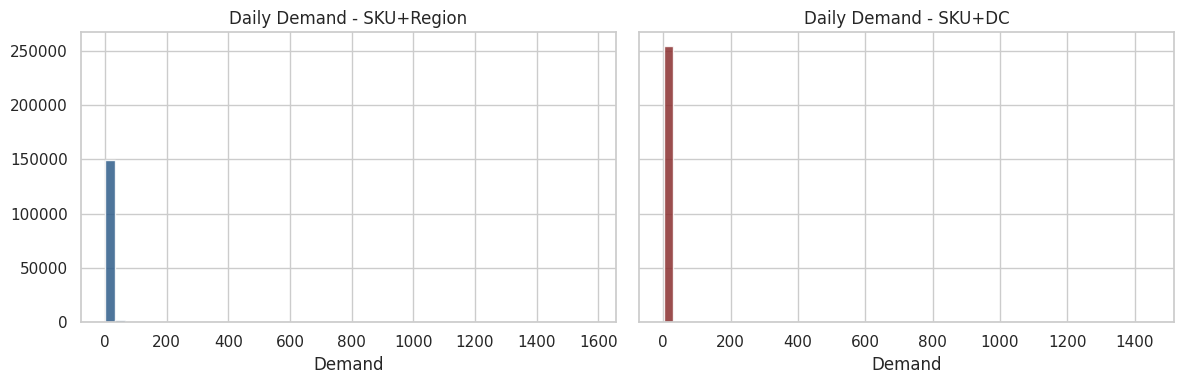

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(daily_by_region['demand'], bins=50, color='#2f5d8a', alpha=0.85)
axes[0].set_title('Daily Demand - SKU+Region')
axes[0].set_xlabel('Demand')
axes[1].hist(daily_by_dc['demand'], bins=50, color='#8a2f2f', alpha=0.85)
axes[1].set_title('Daily Demand - SKU+DC')
axes[1].set_xlabel('Demand')
plt.tight_layout()

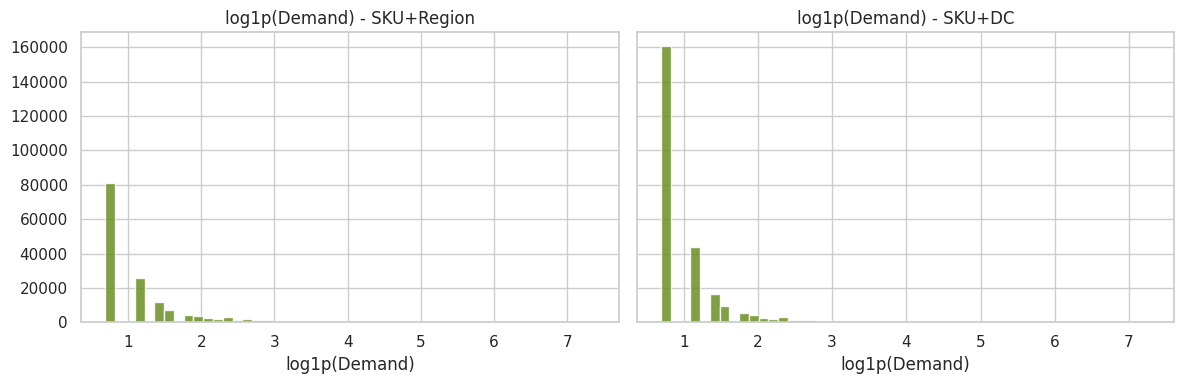

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(np.log1p(daily_by_region['demand']), bins=50, color='#6b8e23', alpha=0.85)
axes[0].set_title('log1p(Demand) - SKU+Region')
axes[0].set_xlabel('log1p(Demand)')
axes[1].hist(np.log1p(daily_by_dc['demand']), bins=50, color='#6b8e23', alpha=0.85)
axes[1].set_title('log1p(Demand) - SKU+DC')
axes[1].set_xlabel('log1p(Demand)')
plt.tight_layout()

## Variance Metrics (Per SKU-Region / SKU-DC)

In [8]:
def variance_metrics(df, group_cols):
    stats = (
        df.groupby(group_cols)['demand']
        .agg(['count', 'mean', 'std', 'min', 'max'])
        .reset_index()
    )
    stats['cv'] = stats['std'] / stats['mean'].replace(0, np.nan)
    return stats

var_region = variance_metrics(daily_by_region, ['sku_ID', 'region_id'])
var_dc = variance_metrics(daily_by_dc, ['sku_ID', 'dc_des'])

display(var_region.head())
display(var_dc.head())

,sku_ID,region_id,count,mean,std,min,max,cv
0,000aa92b82,2.0,3,1.666667,0.57735,1,2,0.34641
1,000aa92b82,4.0,2,1.000000,0.00000,1,1,0.00000
2,000aa92b82,5.0,1,1.000000,NaN,1,1,NaN
3,000aa92b82,9.0,2,1.000000,0.00000,1,1,0.00000
4,000aa92b82,10.0,1,1.000000,NaN,1,1,NaN


,sku_ID,dc_des,count,mean,std,min,max,cv
0,000aa92b82,2,2,1.5,0.707107,1,2,0.471405
1,000aa92b82,4,2,1.0,0.000000,1,1,0.000000
2,000aa92b82,5,1,1.0,NaN,1,1,NaN
3,000aa92b82,9,2,1.0,0.000000,1,1,0.000000
4,000aa92b82,10,1,1.0,NaN,1,1,NaN


In [9]:
def summarize_variance(stats, label):
    cv = stats['cv'].replace([np.inf, -np.inf], np.nan)
    summary = {
        'label': label,
        'groups': len(stats),
        'cv_mean': cv.mean(),
        'cv_median': cv.median(),
        'share_cv_lt_0.1': (cv < 0.1).mean(),
        'share_cv_lt_0.2': (cv < 0.2).mean(),
        'mean_of_means': stats['mean'].mean(),
        'median_of_means': stats['mean'].median(),
        'max_demand': stats['max'].max(),
    }
    return pd.Series(summary)

pd.DataFrame([
    summarize_variance(var_region, 'sku+region'),
    summarize_variance(var_dc, 'sku+dc')
])

,label,groups,cv_mean,cv_median,share_cv_lt_0.1,share_cv_lt_0.2,mean_of_means,median_of_means,max_demand
0,sku+region,30617,0.364688,0.374166,0.217722,0.218375,2.096887,1.0,1577
1,sku+dc,79225,0.326149,0.356348,0.204443,0.204910,1.570856,1.0,1445


## CV Distribution Plots

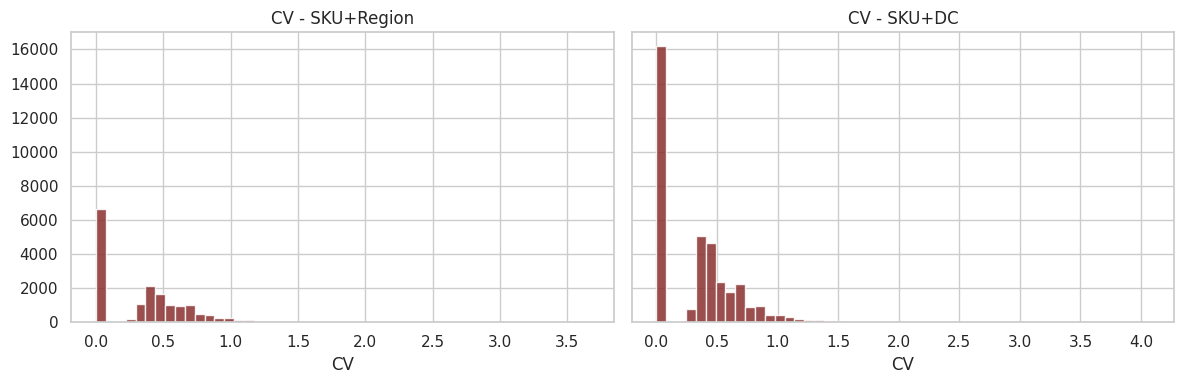

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(var_region['cv'].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, color='#8a2f2f', alpha=0.85)
axes[0].set_title('CV - SKU+Region')
axes[0].set_xlabel('CV')
axes[1].hist(var_dc['cv'].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, color='#8a2f2f', alpha=0.85)
axes[1].set_title('CV - SKU+DC')
axes[1].set_xlabel('CV')
plt.tight_layout()

## Coverage by Date (How Many SKUs Active Per Day)

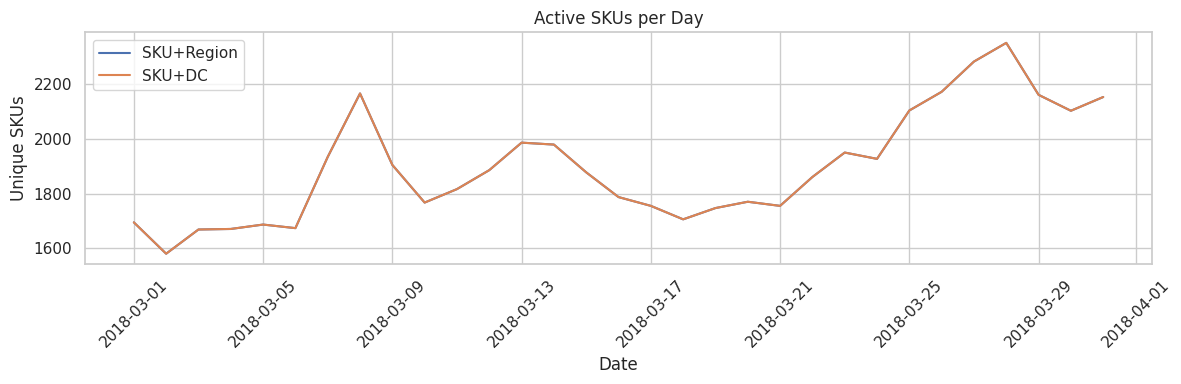

In [11]:
active_skus_region = daily_by_region.groupby('date')['sku_ID'].nunique().sort_index()
active_skus_dc = daily_by_dc.groupby('date')['sku_ID'].nunique().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(active_skus_region.index, active_skus_region.values, label='SKU+Region')
ax.plot(active_skus_dc.index, active_skus_dc.values, label='SKU+DC')
ax.set_title('Active SKUs per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Unique SKUs')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

## Interpreting For Modeling

- Higher sparsity means many SKU-date-region/DC combinations have zero demand, which makes accurate point forecasts harder.
- Compare CV distributions: very low CV suggests near-constant demand (good for baseline models but potentially weak signal for complex models).
- Use the summaries above to decide if `region_id` (less sparse) or `dc_des` (more granular but more sparse) is better for your model.

# **SKU Attributes — Purchased SKUs

Filter `../data/raw/JD_sku_data.csv` to only SKUs present in `../data/raw/JD_order_data.csv` and show aggregate distributions for `type`, `brand_ID`, `attribute1`, and `attribute2`.

This section helps understand the composition of SKUs that actually appear in orders (1P vs 3P, brands, and attribute distributions).

Total unique SKUs in orders: 9159
Total SKUs in SKU file: 31867
SKUs after filtering: 8832

Type counts:
type
2    8531
1     301
Name: count, dtype: int64

Type percentages:
type
2    0.966
1    0.034
Name: count, dtype: float64

Top 20 brands by count:
brand_ID
bd97f9a5fa    249
198cec62a1    215
9b0d3a5fc6    213
4efb032b5a    207
4f65703579    206
3daeabd2ce    169
99d41501ff    132
7fcb433bba    125
fd68e214e8    123
0b0f75e8d5    123
603dc9ab6b    121
42e6445fca    111
dc7e4ae5fc    106
e500aaa647    100
8a5ee0390f     97
3e342224f0     96
7cc01be867     96
7f65198ef6     96
906d0caa60     95
5934e3362b     82
Name: count, dtype: int64

attribute1 unique values: 4
attribute1
3.0    3178
4.0    1612
2.0    1045
1.0     280
Name: count, dtype: int64

attribute2 unique values: 8
attribute2
100.0    3014
60.0     1668
50.0      291
70.0      258
40.0      130
80.0      127
30.0       66
90.0       62
Name: count, dtype: int64


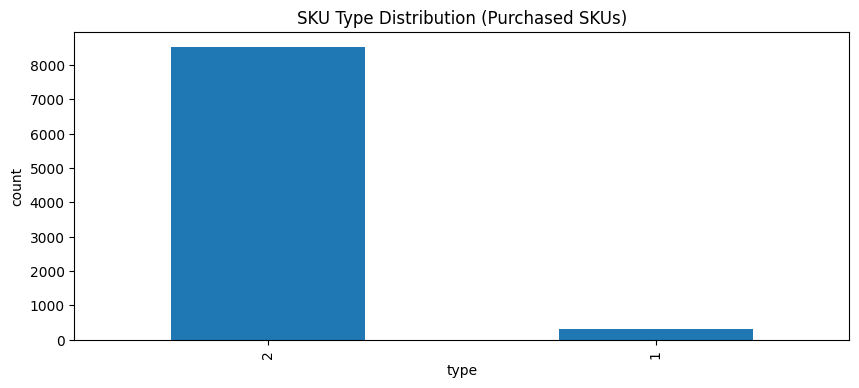

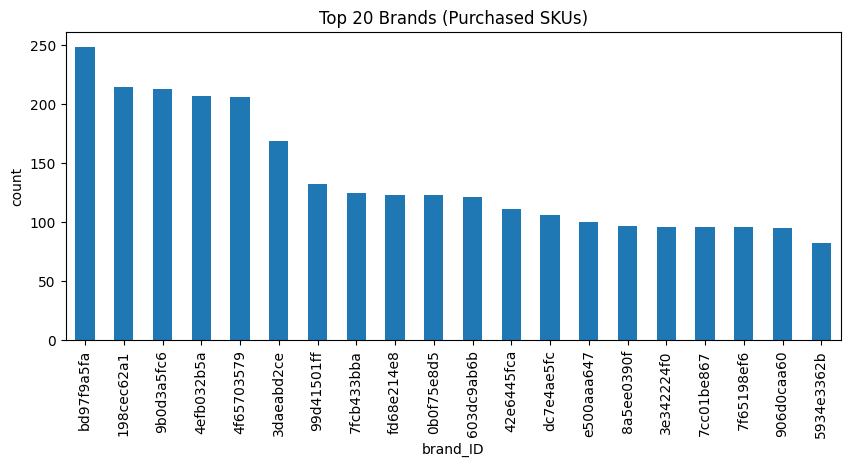

In [1]:
# Analysis: SKU attributes for purchased SKUs
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

root = Path.cwd()
orders_path = root / "../data/raw/JD_order_data.csv"
skus_path = root / "../data/raw/JD_sku_data.csv"

# Read only sku_IDs from orders to keep memory usage low
orders_skus = pd.read_csv(orders_path, usecols=["sku_ID"], dtype={"sku_ID": str})["sku_ID"].dropna().unique()

skus = pd.read_csv(skus_path, dtype={"sku_ID": str})
# Ensure consistent column names
for c in ["type", "brand_ID", "attribute1", "attribute2"]:
    if c not in skus.columns:
        print(f"Warning: expected column {c} not found in {skus_path}")

# Filter to SKUs that appear in orders
skus_filtered = skus[skus["sku_ID"].isin(orders_skus)].copy()

print(f"Total unique SKUs in orders: {len(orders_skus)}")
print(f"Total SKUs in SKU file: {skus['sku_ID'].nunique()}")
print(f"SKUs after filtering: {skus_filtered['sku_ID'].nunique()}\n")

# Type distribution (e.g., 1 = 1P)
type_counts = skus_filtered['type'].fillna('MISSING').astype(str).value_counts()
type_pct = (type_counts / len(skus_filtered)).round(3)
print("Type counts:")
print(type_counts)
print("\nType percentages:")
print(type_pct)

# Brand distribution (top 20)
print('\nTop 20 brands by count:')
print(skus_filtered['brand_ID'].fillna('MISSING').astype(str).value_counts().head(20))

# Attribute distributions
for attr in ['attribute1', 'attribute2']:
    a = skus_filtered[attr].replace('-', pd.NA).dropna()
    print(f"\n{attr} unique values: {a.nunique()}")
    print(a.value_counts().head(20))

# Quick visualizations
plt.figure(figsize=(10,4))
ax = skus_filtered['type'].fillna('MISSING').astype(str).value_counts().plot(kind='bar')
ax.set_title('SKU Type Distribution (Purchased SKUs)')
ax.set_xlabel('type')
ax.set_ylabel('count')
plt.show()

plt.figure(figsize=(10,4))
skus_filtered['brand_ID'].fillna('MISSING').astype(str).value_counts().head(20).plot(kind='bar')
plt.title('Top 20 Brands (Purchased SKUs)')
plt.xlabel('brand_ID')
plt.ylabel('count')
plt.show()

Order counts by sku type:
sku_type
1    275468
2    274521
Name: count, dtype: int64

Ordered quantity sum by sku type:
sku_type
1    338958
2    330197
Name: quantity, dtype: int64

Percent of orders by type:
sku_type
1    0.501
2    0.499
Name: count, dtype: float64


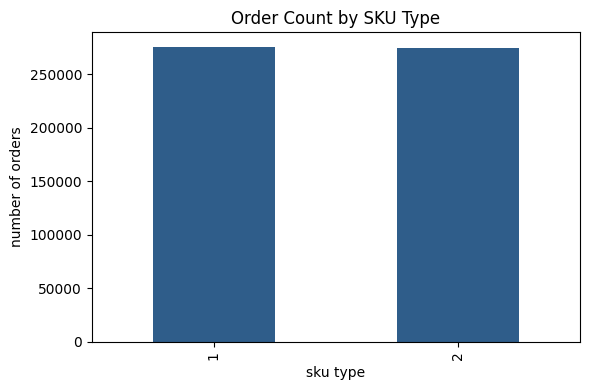

In [6]:
# Orders by SKU `type` (1P vs 3P) — use `type` from orders if available
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
orders_path = root / "../data/raw/JD_order_data.csv"

# Load orders
orders = pd.read_csv(orders_path, dtype={"sku_ID": str})

# Prefer the `type` column in orders; fallback to SKU file if missing
if 'type' in orders.columns:
    orders['sku_type'] = orders['type'].astype(str).fillna('MISSING')
else:
    skus_path = root / '../data/raw/JD_sku_data.csv'
    skus = pd.read_csv(skus_path, dtype={"sku_ID": str})
    if 'type' in skus.columns:
        skus = skus.rename(columns={'type': 'sku_type'})
    else:
        skus['sku_type'] = pd.NA
    orders = orders.merge(skus[['sku_ID', 'sku_type']], on='sku_ID', how='left')
    orders['sku_type'] = orders['sku_type'].fillna('MISSING').astype(str)

# Counts of order rows by SKU type
order_counts = orders['sku_type'].value_counts()
# Sum of ordered quantity by SKU type (if `quantity` exists)
quantity_sum = orders.groupby('sku_type')['quantity'].sum()

print('Order counts by sku type:')
print(order_counts)

print('\nOrdered quantity sum by sku type:')
print(quantity_sum)

print('\nPercent of orders by type:')
print((order_counts / order_counts.sum()).round(3))

# Simple bar plot for quick visualization
plt.figure(figsize=(6,4))
order_counts.plot(kind='bar', color=['#2f5d8a'])
plt.title('Order Count by SKU Type')
plt.xlabel('sku type')
plt.ylabel('number of orders')
plt.tight_layout()
plt.show()

Order composition counts:
composition
all_1p    246912
all_3p    240016
Name: count, dtype: int64

Order composition percentages:
composition
all_1p    0.5071
all_3p    0.4929
Name: count, dtype: float64


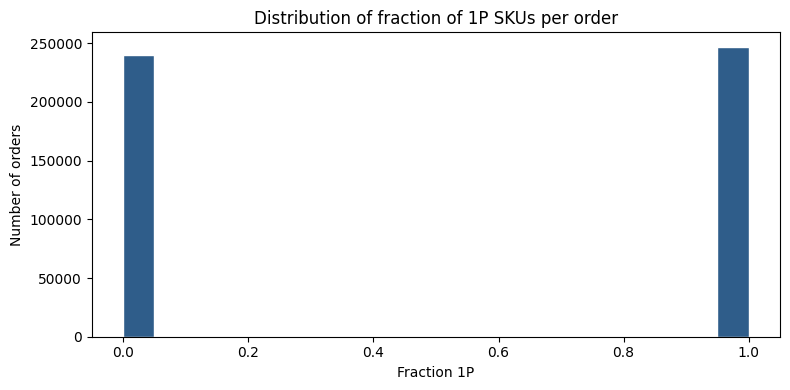


Composition counts by order size (distinct SKU count):
composition  all_1p  all_3p
total_items                
1            222651  220182
2             22171   14139
3              1872    4091
4               180    1402
5                27      48
6                 5     136
7                 2       3
8                 4       4
9                 0       2
10                0       9


In [8]:
# Per-order composition: fraction of 1P vs 3P SKUs (use `type` from orders when present)
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

root = Path.cwd()
orders_path = root / "../data/raw/JD_order_data.csv"
skus_path = root / "../data/raw/JD_sku_data.csv"

# Load orders
orders = pd.read_csv(orders_path, dtype={"order_ID": str, "sku_ID": str})

# Use `type` from orders if present; otherwise join SKU file
if 'type' in orders.columns:
    orders['sku_type'] = orders['type'].astype(str).fillna('MISSING')
else:
    skus = pd.read_csv(skus_path, dtype={"sku_ID": str})
    if 'type' in skus.columns:
        skus = skus.rename(columns={'type': 'sku_type'})
    else:
        skus['sku_type'] = pd.NA
    orders = orders.merge(skus[['sku_ID', 'sku_type']], on='sku_ID', how='left')
    orders['sku_type'] = orders['sku_type'].fillna('MISSING').astype(str)

# Use unique (order_ID, sku_ID) rows as requested
order_items = orders[['order_ID', 'sku_ID', 'sku_type']].drop_duplicates()
order_items['sku_ID'] = order_items['sku_ID'].astype(str)

# Flag 1P SKUs (we treat the value '1' as 1P)
order_items['is_1p'] = order_items['sku_type'] == '1'
order_items['is_missing'] = order_items['sku_type'] == 'MISSING'

per_order = (
    order_items.groupby('order_ID', as_index=False)
    .agg(
        total_items=('sku_ID', 'nunique'),
        n_1p=('is_1p', 'sum'),
        n_missing=('is_missing', 'sum'),
    )
)
per_order['frac_1p'] = per_order['n_1p'] / per_order['total_items']

# Classify composition
def classify(r):
    if r['n_missing'] > 0:
        return 'contains_missing_sku_info'
    if r['frac_1p'] == 1.0:
        return 'all_1p'
    if r['frac_1p'] == 0.0:
        return 'all_3p'
    return 'mixed'

per_order['composition'] = per_order.apply(classify, axis=1)

counts = per_order['composition'].value_counts()
percents = (counts / counts.sum()).round(4)

print('Order composition counts:')
print(counts)
print('\nOrder composition percentages:')
print(percents)

# Show distribution of fraction of 1P in orders
plt.figure(figsize=(8,4))
plt.hist(per_order['frac_1p'].dropna(), bins=20, color='#2f5d8a', edgecolor='white')
plt.title('Distribution of fraction of 1P SKUs per order')
plt.xlabel('Fraction 1P')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

# Show breakdown by order size (number of distinct SKUs)
size_breakdown = (
    per_order.groupby('total_items')['composition']
    .value_counts()
    .unstack(fill_value=0)
)
print('\nComposition counts by order size (distinct SKU count):')
print(size_breakdown.head(20))

In [9]:
# in the notebook where `per_order` exists
print(per_order['composition'].value_counts())
total = len(per_order)
mixed = per_order['composition'].value_counts().get('mixed', 0)
print(f"mixed orders: {mixed} ({mixed/total:.2%})")

composition
all_1p    246912
all_3p    240016
Name: count, dtype: int64
mixed orders: 0 (0.00%)


SKUs in SKU file: 31,867
Purchased SKUs (unique in orders): 9,159
Purchased SKUs found in SKU file: 8,832

=== attribute1 ===
Total SKUs considered: 8832
Null / missing attribute1: 2717 (30.76%)
count    6115.000000
mean        3.001145
std         0.785978
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         4.000000
Name: attribute1, dtype: float64


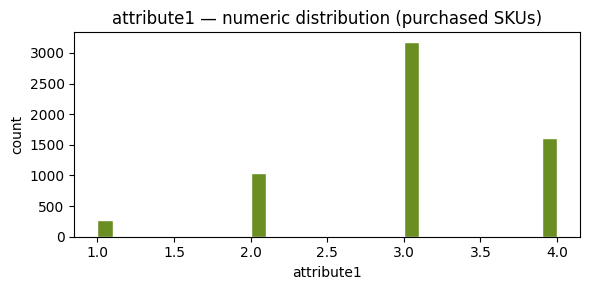



=== attribute2 ===
Total SKUs considered: 8832
Null / missing attribute2: 3216 (36.41%)
count    5616.000000
mean       81.376425
std        21.222899
min        30.000000
25%        60.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: attribute2, dtype: float64


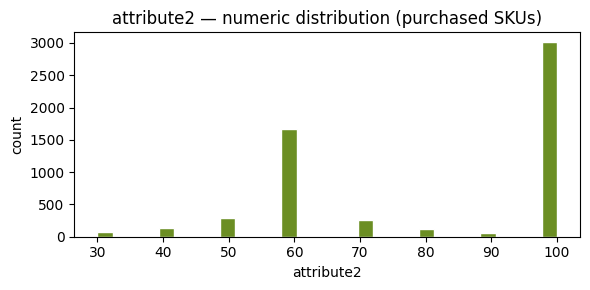

,attribute,total,nulls,pct_null,n_unique
0,attribute1,8832,2717,0.307631,4
1,attribute2,8832,3216,0.364130,8


In [10]:
# Purchased SKUs: detailed attribute1 / attribute2 distributions
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

root = Path.cwd()
orders_path = root / "../data/raw/JD_order_data.csv"
skus_path = root / "../data/raw/JD_sku_data.csv"

# Load purchased SKU IDs and SKU master
orders_skus = pd.read_csv(orders_path, usecols=["sku_ID"], dtype={"sku_ID": str})["sku_ID"].dropna().unique()
skus = pd.read_csv(skus_path, dtype={"sku_ID": str})
skus_filtered = skus[skus["sku_ID"].isin(orders_skus)].copy()

print(f"SKUs in SKU file: {skus['sku_ID'].nunique():,}")
print(f"Purchased SKUs (unique in orders): {len(orders_skus):,}")
print(f"Purchased SKUs found in SKU file: {skus_filtered['sku_ID'].nunique():,}\n")

for attr in ['attribute1', 'attribute2']:
    print(f"=== {attr} ===")
    if attr not in skus_filtered.columns:
        print(f"Column {attr} not found in SKU file.\n")
        continue

    s = skus_filtered[attr].replace('-', pd.NA)
    n_total = len(skus_filtered)
    n_null = int(s.isna().sum())
    pct_null = n_null / n_total if n_total else 0

    print(f"Total SKUs considered: {n_total}")
    print(f"Null / missing {attr}: {n_null} ({pct_null:.2%})")

    # Attempt numeric conversion
    s_num = pd.to_numeric(s, errors='coerce')
    n_numeric = s_num.notna().sum()

    if n_numeric > 0 and n_numeric / (n_total - n_null + 1e-9) > 0.1:
        # Enough numeric values to summarize
        print(s_num.describe())
        plt.figure(figsize=(6,3))
        plt.hist(s_num.dropna(), bins=30, color='#6b8e23', edgecolor='white')
        plt.title(f'{attr} — numeric distribution (purchased SKUs)')
        plt.xlabel(attr)
        plt.ylabel('count')
        plt.tight_layout()
        plt.show()
    else:
        # Categorical summary
        vc = s.dropna().astype(str).value_counts()
        print(f"Unique non-null values: {vc.size}")
        print(vc.head(30))
        if vc.size > 0:
            plt.figure(figsize=(8,3))
            vc.head(20).plot(kind='bar', color='#2f5d8a')
            plt.title(f'{attr} — top values (purchased SKUs)')
            plt.xlabel(attr)
            plt.ylabel('count')
            plt.tight_layout()
            plt.show()
    print('\n')

# Optionally export summary table
attr_summary = []
for attr in ['attribute1', 'attribute2']:
    if attr in skus_filtered.columns:
        s = skus_filtered[attr].replace('-', pd.NA)
        n_total = len(skus_filtered)
        n_null = int(s.isna().sum())
        pct_null = n_null / n_total if n_total else 0
        n_unique = s.dropna().nunique()
        attr_summary.append({'attribute': attr, 'total': n_total, 'nulls': n_null, 'pct_null': pct_null, 'n_unique': n_unique})

if attr_summary:
    summary_df = pd.DataFrame(attr_summary)
    display(summary_df)
    # summary_df.to_csv('purchased_skus_attribute_summary.csv', index=False)